# Task 1: Potential Problems in Linear Regression

## Potential Problem 1: Non-linearity of the Response-Predictor Relationships

When fitting a linear regression model we assume that there is a linear relationship between predictors and response variables. If the relationship is anything but a linear relationship then the conclusions made from the model may be misleading. To determine if the relationship is linear, we can utilize residual plots, where the residuals is plotted against the predictor variable. If there truly is a straight-linear relationship then there will be no patterns within the plot, and the residual line should follow closely near zero. 

A question that came up was if there is a non-linear relationship, what is the next step in ensuring that there is no pattern within the plot. The textbook implies that you could add transformations to the predictor variables, but how do we know which transformation is the best approach? The best transformation depends on the shape of the residual plot. Where a U-shaped may suggest a square polynomial or an inverted U-shaped curve would suggest a log or square root transformation. After transforming the predictor variables we would need to refit the model and replot the Residual plot to check the pattern and relationship of the residuals and the predictor variables.



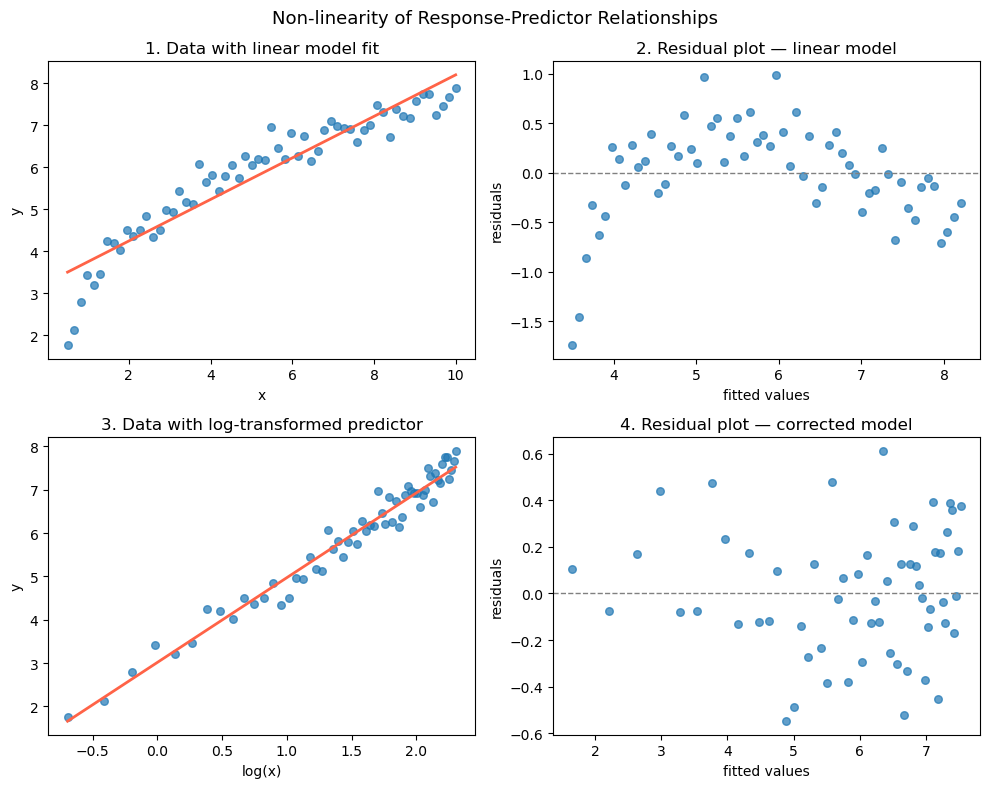

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 60
x = np.linspace(0.5, 10, n)
y = 2 * np.log(x) + 3 + np.random.normal(0, 0.3, n)

# Linear model fit (raw x)
a1, a0 = np.polyfit(x, y, 1)
fitted_linear = a0 + a1 * x
resid_linear = y - fitted_linear

# Log-transformed model
log_x = np.log(x)
b1, b0 = np.polyfit(log_x, y, 1)
fitted_log = b0 + b1 * log_x
resid_log = y - fitted_log

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Non-linearity of Response-Predictor Relationships", fontsize=13)

axes[0, 0].scatter(x, y, alpha=0.7, s=30)
axes[0, 0].plot(x, fitted_linear, color="tomato", linewidth=2)
axes[0, 0].set_title("1. Data with linear model fit")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")

axes[0, 1].scatter(fitted_linear, resid_linear, alpha=0.7, s=30)
axes[0, 1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0, 1].set_title("2. Residual plot — linear model")
axes[0, 1].set_xlabel("fitted values")
axes[0, 1].set_ylabel("residuals")

axes[1, 0].scatter(log_x, y, alpha=0.7, s=30)
axes[1, 0].plot(log_x, fitted_log, color="tomato", linewidth=2)
axes[1, 0].set_title("3. Data with log-transformed predictor")
axes[1, 0].set_xlabel("log(x)")
axes[1, 0].set_ylabel("y")

axes[1, 1].scatter(fitted_log, resid_log, alpha=0.7, s=30)
axes[1, 1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1, 1].set_title("4. Residual plot — corrected model")
axes[1, 1].set_xlabel("fitted values")
axes[1, 1].set_ylabel("residuals")

plt.tight_layout()
plt.show()

Plot 1 shows the raw data with a linear model fit to it, here we can see that the model is a poor fit as the data follows a curve (a non-linear relationship). Which is proven in plot 2, where the Residual plot follows a inverted U-shaped curve. Plot 3 demonstrates a better fit to the data after a log-transformation was applied to the predictor variable. Plot 4 represents the ideal Residual plot with randomly scattered points around zero. These plots represents the approach that could be taken when encountering non-linearity of response-predictor variables.

## Potential Problem 2: Correlation of Error Terms

Another assumption we make with linear regression models is that the error terms are uncorrelated. This means that $\epsilon_i$ has no influence on $\epsilon_{i+1}$. This is a key assumption because this then affects the standard errors that are computed directly from these error values. Correlation amongst the error terms would lead to estimated standard errors that would underestimate the true standard error which can then affect confidence intervals. To determine if there is correlation within the error terms, residuals can be plotted as a function of time, where we are looking for no discernable patterns.

A question that came up was, when determining correlation amongst the error terms are there other plots that can be used, as the explained plotting method seems to be used in time series data? Upon research, I found that a lagged residual plot where $\epsilon_i$ is plotted against $\epsilon_{i+1}$ and we would expect random scatter to ensure no correlation between the error terms.


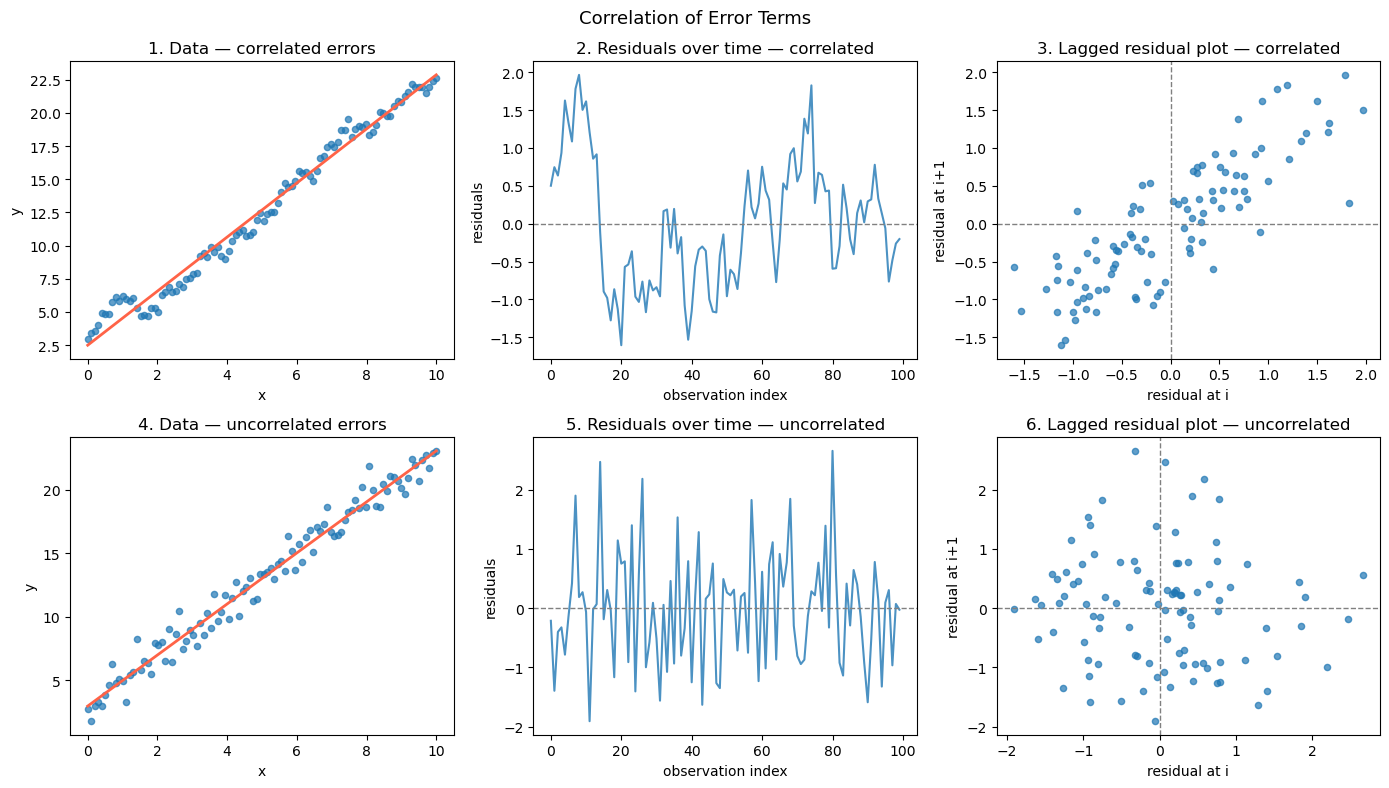

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 100
x = np.linspace(0, 10, n)

# Correlated errors using AR(1) process
rho = 0.85
errors = np.zeros(n)
for i in range(1, n):
    errors[i] = rho * errors[i-1] + np.random.normal(0, 0.5)

y_corr = 2 * x + 3 + errors

# Uncorrelated errors (fixed)
y_uncorr = 2 * x + 3 + np.random.normal(0, 1, n)

def fit_residuals(x, y):
    b1, b0 = np.polyfit(x, y, 1)
    fitted = b0 + b1 * x
    return fitted, y - fitted

fitted_corr, resid_corr = fit_residuals(x, y_corr)
fitted_uncorr, resid_uncorr = fit_residuals(x, y_uncorr)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Correlation of Error Terms", fontsize=13)

# Row 1: correlated errors
axes[0, 0].scatter(x, y_corr, alpha=0.7, s=20)
axes[0, 0].plot(x, fitted_corr, color="tomato", linewidth=2)
axes[0, 0].set_title("1. Data — correlated errors")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")

axes[0, 1].plot(range(n), resid_corr, alpha=0.8)
axes[0, 1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0, 1].set_title("2. Residuals over time — correlated")
axes[0, 1].set_xlabel("observation index")
axes[0, 1].set_ylabel("residuals")

axes[0, 2].scatter(resid_corr[:-1], resid_corr[1:], alpha=0.7, s=20)
axes[0, 2].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0, 2].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[0, 2].set_title("3. Lagged residual plot — correlated")
axes[0, 2].set_xlabel("residual at i")
axes[0, 2].set_ylabel("residual at i+1")

# Row 2: uncorrelated errors
axes[1, 0].scatter(x, y_uncorr, alpha=0.7, s=20)
axes[1, 0].plot(x, fitted_uncorr, color="tomato", linewidth=2)
axes[1, 0].set_title("4. Data — uncorrelated errors")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("y")

axes[1, 1].plot(range(n), resid_uncorr, alpha=0.8)
axes[1, 1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1, 1].set_title("5. Residuals over time — uncorrelated")
axes[1, 1].set_xlabel("observation index")
axes[1, 1].set_ylabel("residuals")

axes[1, 2].scatter(resid_uncorr[:-1], resid_uncorr[1:], alpha=0.7, s=20)
axes[1, 2].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1, 2].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[1, 2].set_title("6. Lagged residual plot — uncorrelated")
axes[1, 2].set_xlabel("residual at i")
axes[1, 2].set_ylabel("residual at i+1")

plt.tight_layout()
plt.show()

Plots 2-3 display correlated error terms. This is shown my the spike and decline pattern within Plot 2 and the linear pattern show in the Lagged residual plot. Plots 4-6 represents data where the error terms are uncorrelated. Plot 5 displays the random trend we'd expect to see of the residuals over time in error terms that are uncorrelated. The Lagged residual plot 6, also displays the random pattern we'd expect to see from error terms that are uncorrelated.

## Potential Problem 3: Outliers

An outlier is an observation where the predicted model lies far from. Outliers can be a result of incorrect data input, natural variability, or measurement errors. While keeping or removing an outlier may not have an effect on the fit of a model, it can cause other problems. A issue outliers can cause is influencing the scale of the RSE, which then impacts the confidence interval. Another issue is influencing the $R^2$ value, leading to over or under estimation of understanding how well the model explains the variability of the data. A way to detect outliers is within Residual plots, however a studentized residuals plot provides a metric to determine if an observation is truly a outlier, rather than relying on our best judgement.

A question that came up was, how many observations must follow the outlier trend/positioning for an observation to no longer be a outlier? The best way to answer this question would be to rely on the plotting methods such as the studentized residuals plot to determine when an observation is an outlier or not. In general, it seems that once another observation joins the positioning/trend of an outlier, then those observations would no longer be considered outliers, as now these observations become a part of the general trend of the data.

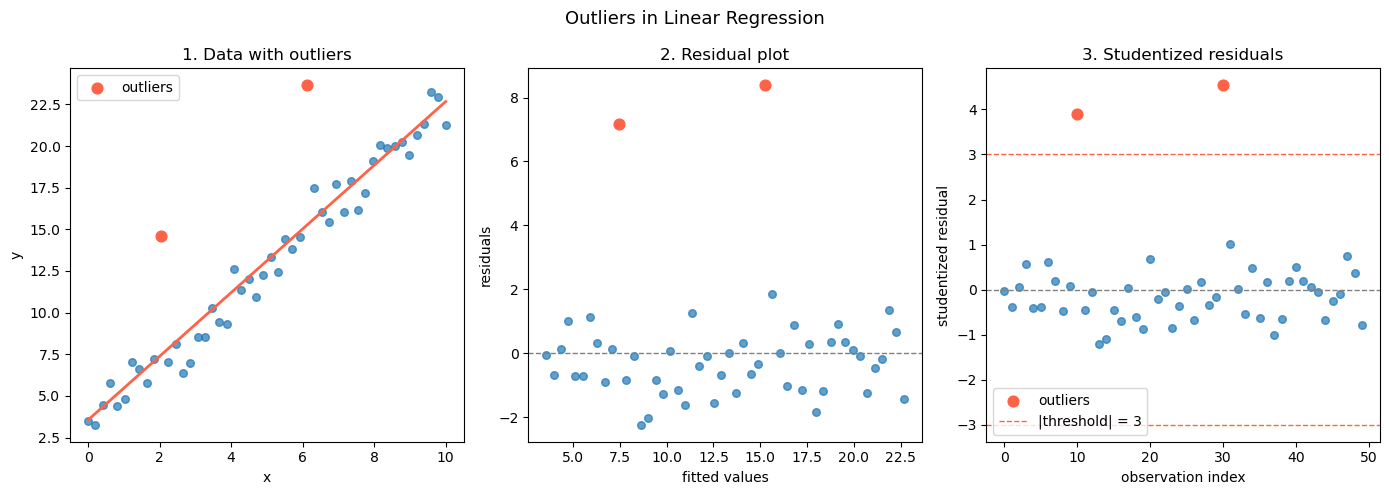

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
n = 50
x = np.linspace(0, 10, n)
y = 2 * x + 3 + np.random.normal(0, 1, n)

# Inject outliers
y[10] += 8
y[30] += 9

def fit(x, y):
    b1, b0 = np.polyfit(x, y, 1)
    fitted = b0 + b1 * x
    resid = y - fitted
    return fitted, resid

fitted, resid = fit(x, y)

# Studentized residuals
def studentized_residuals(x, resid):
    n = len(x)
    x_mean = np.mean(x)
    h = 1/n + (x - x_mean)**2 / np.sum((x - x_mean)**2)  # leverage
    mse = np.sum(resid**2) / (n - 2)
    std_resid = resid / np.sqrt(mse * (1 - h))
    return std_resid

stud_resid = studentized_residuals(x, resid)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Outliers in Linear Regression", fontsize=13)

# Plot 1: data + fit
axes[0].scatter(x, y, alpha=0.7, s=30)
axes[0].plot(x, fitted, color="tomato", linewidth=2)
axes[0].scatter(x[[10, 30]], y[[10, 30]], color="tomato", s=60, zorder=5, label="outliers")
axes[0].set_title("1. Data with outliers")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Plot 2: residual plot
axes[1].scatter(fitted, resid, alpha=0.7, s=30)
axes[1].scatter(fitted[[10, 30]], resid[[10, 30]], color="tomato", s=60, zorder=5)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("2. Residual plot")
axes[1].set_xlabel("fitted values")
axes[1].set_ylabel("residuals")

# Plot 3: studentized residuals
axes[2].scatter(range(n), stud_resid, alpha=0.7, s=30)
axes[2].scatter([10, 30], stud_resid[[10, 30]], color="tomato", s=60, zorder=5, label="outliers")
axes[2].axhline(3,  color="tomato", linestyle="--", linewidth=1, label="|threshold| = 3")
axes[2].axhline(-3, color="tomato", linestyle="--", linewidth=1)
axes[2].axhline(0,  color="gray",   linestyle="--", linewidth=1)
axes[2].set_title("3. Studentized residuals")
axes[2].set_xlabel("observation index")
axes[2].set_ylabel("studentized residual")
axes[2].legend()

plt.tight_layout()
plt.show()

Plot 1 displays the predictor variable plotted against the response variable, highlighting two outliers. The Residual plot also highlights the outliers that fall outside the random scatter, indicating that these are observations with large residuals. Studentized residuals plot provides a clear threshold of identifying outliers within data. This could be helpful when an outlier identified in a Residual plot falls slightly closer to the main cloud, but could possibly be outliers.

### Generative AI Reflection

I used Claude to generate synthetic data and the plots of each potential problems in linear regression. For each issue, I pasted the prompt from the assignment asking Claude to generate synthetic data that clearly illustrates the potential issue, then to produce plots making the issue visually clear, and then to produces additional plots showing how the issue can be addressed. I specifically asked Claude to provide me an example of the answer I researched for the question I came up with during reading. When prompting Claude with my first issue, the problems I ran into were the format in which Claude was returning code, where it provide me an html and actual py file. After fine tuning the prompts it was easy to obtain the plots I was looking for. I think Claude did a good job at providing simple plots that were easy to understand and relate back to the potential issue.